# ⏰ Astoria Dry Cleaning — Peak Demand Timing Analysis

### Objectives
1. Identify **peak booking hours** throughout the day
2. Analyse **day-of-week** demand patterns
3. Track **monthly & seasonal** trends over time
4. Map **collection slot** and **delivery slot** demand
5. Break down peak periods **by zone**
6. Forecast **rider requirements** during high-demand windows
7. Produce actionable **slot scheduling recommendations**

### Key Columns
| Column | Description |
|---|---|
| `booking_date` | Date the order was placed |
| `booking_time` | Exact time (HH:MM) the order was placed |
| `booking_hour` | Hour of booking (0–23) |
| `booking_day_of_week` | Day name (Monday–Saturday) |
| `collection_time` | Time driver collected the order |
| `delivery_slot` | Assigned delivery window (09:00-13:00, 12:00-16:00, 15:00-18:00) |
| `zone` | Customer delivery zone |
| `order_value_sgd` | Revenue per order |

---
## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 10,
})

# Colour constants
C_BLUE   = '#2196F3'
C_ORANGE = '#FF5722'
C_GREEN  = '#4CAF50'
C_PURPLE = '#9C27B0'
C_AMBER  = '#FFC107'
ZONE_PALETTE = [
    '#2196F3','#FF5722','#4CAF50','#9C27B0',
    '#FF9800','#00BCD4','#E91E63','#795548','#607D8B','#009688'
]

print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../../data1/astoria_orders.csv')

# Parse dates & times
df['booking_date']    = pd.to_datetime(df['booking_date'])
df['collection_date'] = pd.to_datetime(df['collection_date'])
df['delivery_date']   = pd.to_datetime(df['delivery_date'])

# Derived time columns
df['booking_month']      = df['booking_date'].dt.month
df['booking_month_name'] = df['booking_date'].dt.strftime('%b')
df['booking_year']       = df['booking_date'].dt.year
df['booking_week']       = df['booking_date'].dt.isocalendar().week.astype(int)
df['year_month']         = df['booking_date'].dt.to_period('M')
df['collection_hour']    = df['collection_time'].str.split(':').str[0].astype(int)

# Hour period labels
def hour_period(h):
    if 0  <= h < 6:  return 'Late Night (0-5)'
    if 6  <= h < 9:  return 'Early Morning (6-8)'
    if 9  <= h < 12: return 'Morning (9-11)'
    if 12 <= h < 14: return 'Lunch (12-13)'
    if 14 <= h < 18: return 'Afternoon (14-17)'
    if 18 <= h < 21: return 'Evening (18-20)'
    return 'Night (21-23)'

df['booking_period'] = df['booking_hour'].apply(hour_period)

print(f'Orders loaded : {len(df):,}')
print(f'Date range    : {df.booking_date.min().date()} to {df.booking_date.max().date()}')
print(f'Zones         : {df.zone.nunique()}')
print(f'\nBooking hour range: {df.booking_hour.min()} - {df.booking_hour.max()}')
df[['booking_date','booking_time','booking_hour','booking_period',
    'collection_time','delivery_slot','zone','order_value_sgd']].head(5)

Orders loaded : 5,000
Date range    : 2024-01-01 to 2025-06-27
Zones         : 20

Booking hour range: 0 - 23


,booking_date,booking_time,booking_hour,booking_period,collection_time,delivery_slot,zone,order_value_sgd
0,2024-06-07,11:15,11,Morning (9-11),14:46,15:00-18:00,Choa Chu Kang / Bukit Panjang,8.83
1,2024-03-23,11:24,11,Morning (9-11),16:07,15:00-18:00,Buona Vista / Holland,35.73
2,2024-04-19,10:08,10,Morning (9-11),15:55,12:00-16:00,Choa Chu Kang / Bukit Panjang,117.66
3,2024-08-30,21:25,21,Night (21-23),11:31,15:00-18:00,Punggol / Sengkang,53.35
4,2024-11-01,10:33,10,Morning (9-11),12:13,09:00-13:00,Tampines / Pasir Ris,29.73


---
## 2. Hourly Booking Pattern
When do customers place orders throughout the day? This drives when staff must be ready to respond and riders dispatched.

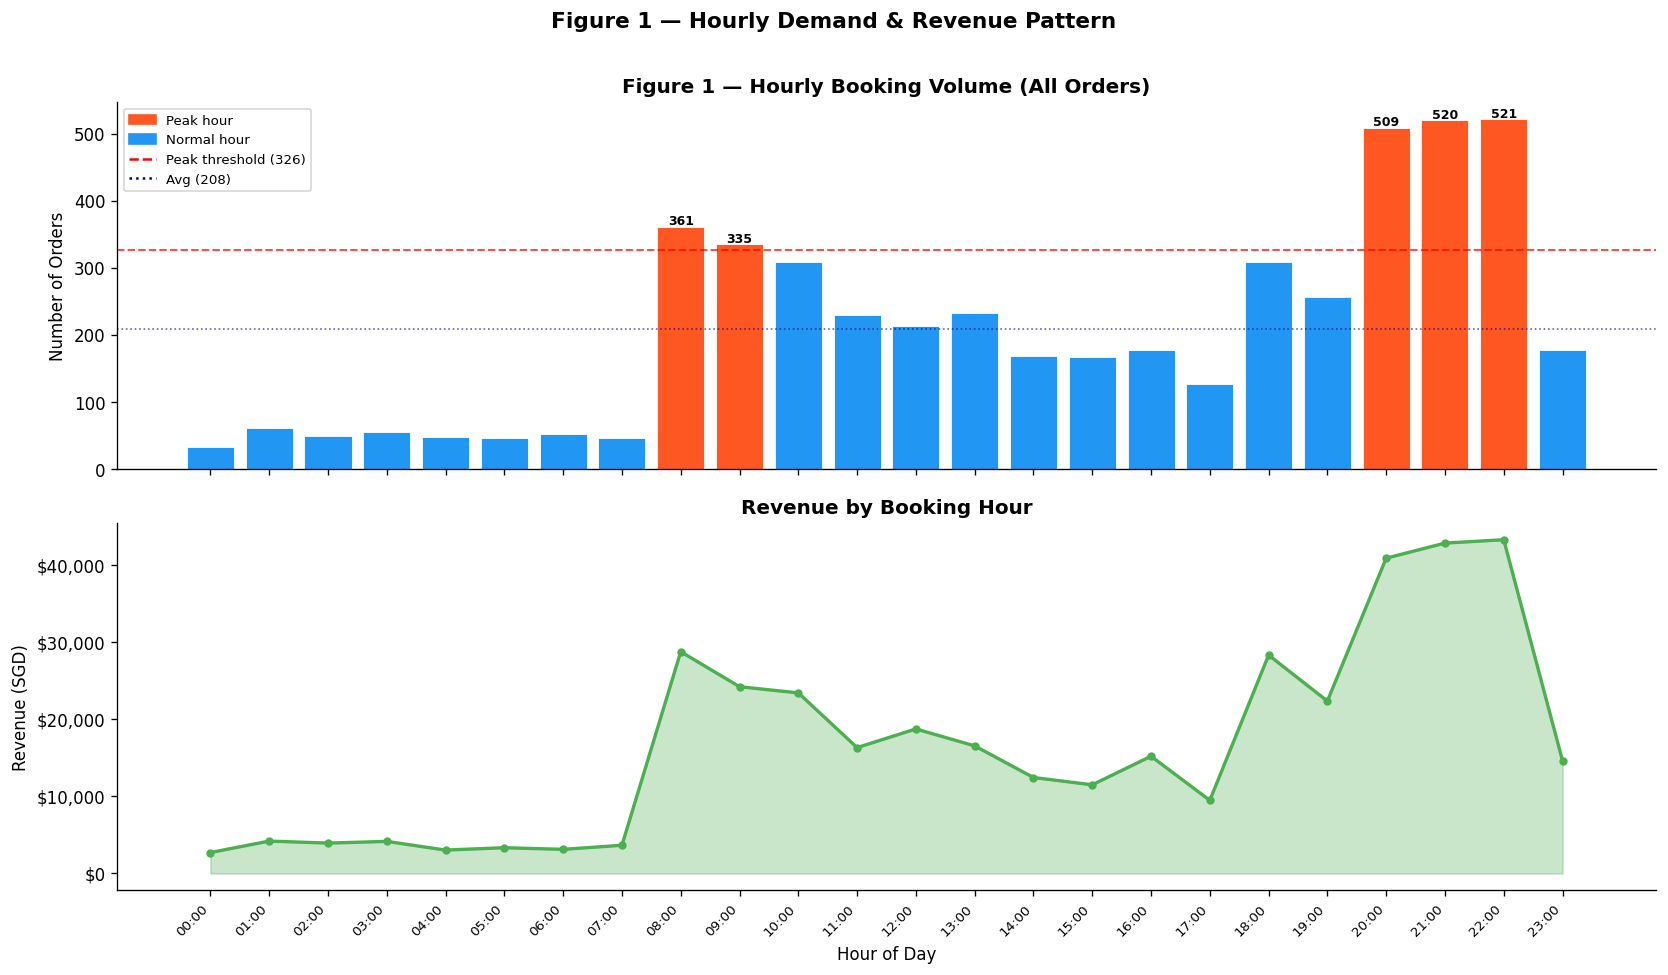

Peak hours identified: ['08:00', '09:00', '20:00', '21:00', '22:00']
Peak orders share    : 44.9% of all bookings


In [3]:
hourly = df.groupby('booking_hour').agg(
    orders  = ('order_id',       'count'),
    revenue = ('order_value_sgd', 'sum'),
).reset_index()
hourly['order_pct'] = (hourly['orders'] / hourly['orders'].sum() * 100).round(1)
hourly['hour_label'] = hourly['booking_hour'].apply(lambda h: f'{h:02d}:00')

# Identify peaks: above mean + 0.75 std
threshold = hourly['orders'].mean() + 0.75 * hourly['orders'].std()
hourly['is_peak'] = hourly['orders'] > threshold

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: order volume bars
ax = axes[0]
bar_colors = [C_ORANGE if p else C_BLUE for p in hourly['is_peak']]
bars = ax.bar(hourly['booking_hour'], hourly['orders'], color=bar_colors,
              edgecolor='white', linewidth=0.5, width=0.8)
ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Peak threshold ({threshold:.0f})')
ax.axhline(hourly['orders'].mean(), color='navy', linestyle=':', linewidth=1, alpha=0.6, label=f'Avg ({hourly["orders"].mean():.0f})')
for bar, row in zip(bars, hourly.itertuples()):
    if row.is_peak:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                f'{row.orders}', ha='center', fontsize=7.5, color='black', fontweight='bold')
ax.set_ylabel('Number of Orders')
ax.set_title('Figure 1 — Hourly Booking Volume (All Orders)', fontweight='bold')
ax.legend(fontsize=9)
peak_patch = mpatches.Patch(color=C_ORANGE, label='Peak hour')
norm_patch = mpatches.Patch(color=C_BLUE,   label='Normal hour')
ax.legend(handles=[peak_patch, norm_patch,
    plt.Line2D([0],[0], color='red',  linestyle='--', label=f'Peak threshold ({threshold:.0f})'),
    plt.Line2D([0],[0], color='navy', linestyle=':',  label=f'Avg ({hourly["orders"].mean():.0f})')],
    fontsize=8, loc='upper left')

# Bottom: revenue
ax2 = axes[1]
ax2.fill_between(hourly['booking_hour'], hourly['revenue'], alpha=0.3, color=C_GREEN)
ax2.plot(hourly['booking_hour'], hourly['revenue'], color=C_GREEN, linewidth=2, marker='o', markersize=4)
ax2.set_ylabel('Revenue (SGD)')
ax2.set_xlabel('Hour of Day')
ax2.set_title('Revenue by Booking Hour', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.set_xticks(range(0,24))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)

plt.suptitle('Figure 1 — Hourly Demand & Revenue Pattern', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_hourly_pattern.png', bbox_inches='tight')
plt.show()

peak_hours = hourly[hourly['is_peak']]['booking_hour'].tolist()
print(f'Peak hours identified: {[f"{h:02d}:00" for h in peak_hours]}')
print(f'Peak orders share    : {hourly[hourly["is_peak"]]["order_pct"].sum():.1f}% of all bookings')

---
## 3. Booking Period Summary
Group hours into named periods to simplify scheduling decisions.

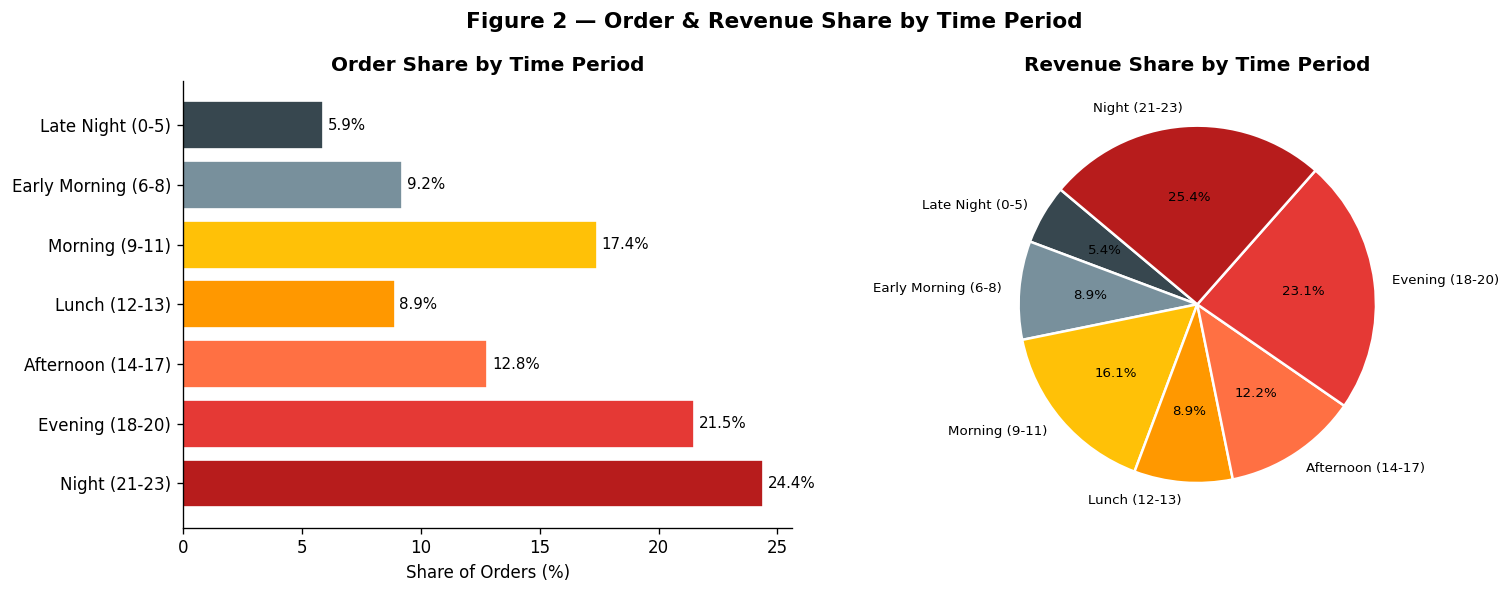

'     booking_period  orders  order_pct   revenue  revenue_pct   avg_val\n   Late Night (0-5)     293        5.9  21331.88          5.4 72.805051\nEarly Morning (6-8)     459        9.2  35522.95          8.9 77.392048\n     Morning (9-11)     872       17.4  63950.91         16.1 73.338200\n      Lunch (12-13)     445        8.9  35278.39          8.9 79.277281\n  Afternoon (14-17)     639       12.8  48600.41         12.2 76.056980\n    Evening (18-20)    1074       21.5  91561.49         23.1 85.252784\n      Night (21-23)    1218       24.4 100742.04         25.4 82.711034'

In [4]:
PERIOD_ORDER = [
    'Late Night (0-5)', 'Early Morning (6-8)', 'Morning (9-11)',
    'Lunch (12-13)', 'Afternoon (14-17)', 'Evening (18-20)', 'Night (21-23)'
]
period_summary = (
    df.groupby('booking_period')
    .agg(
        orders  = ('order_id',        'count'),
        revenue = ('order_value_sgd',  'sum'),
        avg_val = ('order_value_sgd',  'mean'),
    )
    .reindex([p for p in PERIOD_ORDER if p in df['booking_period'].unique()])
    .reset_index()
)
period_summary['order_pct']   = (period_summary['orders']  / period_summary['orders'].sum()  * 100).round(1)
period_summary['revenue_pct'] = (period_summary['revenue'] / period_summary['revenue'].sum() * 100).round(1)

PERIOD_COLOURS = {
    'Late Night (0-5)':       '#37474F',
    'Early Morning (6-8)':    '#78909C',
    'Morning (9-11)':         '#FFC107',
    'Lunch (12-13)':          '#FF9800',
    'Afternoon (14-17)':      '#FF7043',
    'Evening (18-20)':        '#E53935',
    'Night (21-23)':          '#B71C1C',
}
p_colours = [PERIOD_COLOURS.get(p, C_BLUE) for p in period_summary['booking_period']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Horizontal bar — orders
bars = axes[0].barh(period_summary['booking_period'], period_summary['order_pct'],
                    color=p_colours, edgecolor='white')
for bar, v in zip(bars, period_summary['order_pct']):
    axes[0].text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                 f'{v}%', va='center', fontsize=9)
axes[0].set_xlabel('Share of Orders (%)')
axes[0].set_title('Order Share by Time Period')
axes[0].invert_yaxis()

# Pie — revenue share
axes[1].pie(period_summary['revenue_pct'],
            labels=period_summary['booking_period'],
            autopct='%1.1f%%', colors=p_colours,
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5},
            textprops={'fontsize': 8})
axes[1].set_title('Revenue Share by Time Period')

plt.suptitle('Figure 2 — Order & Revenue Share by Time Period', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_period_summary.png', bbox_inches='tight')
plt.show()

display(period_summary[['booking_period','orders','order_pct','revenue','revenue_pct','avg_val']].to_string(index=False))

---
## 4. Day-of-Week Demand Pattern
Which days of the week are busiest? This informs rider roster scheduling.

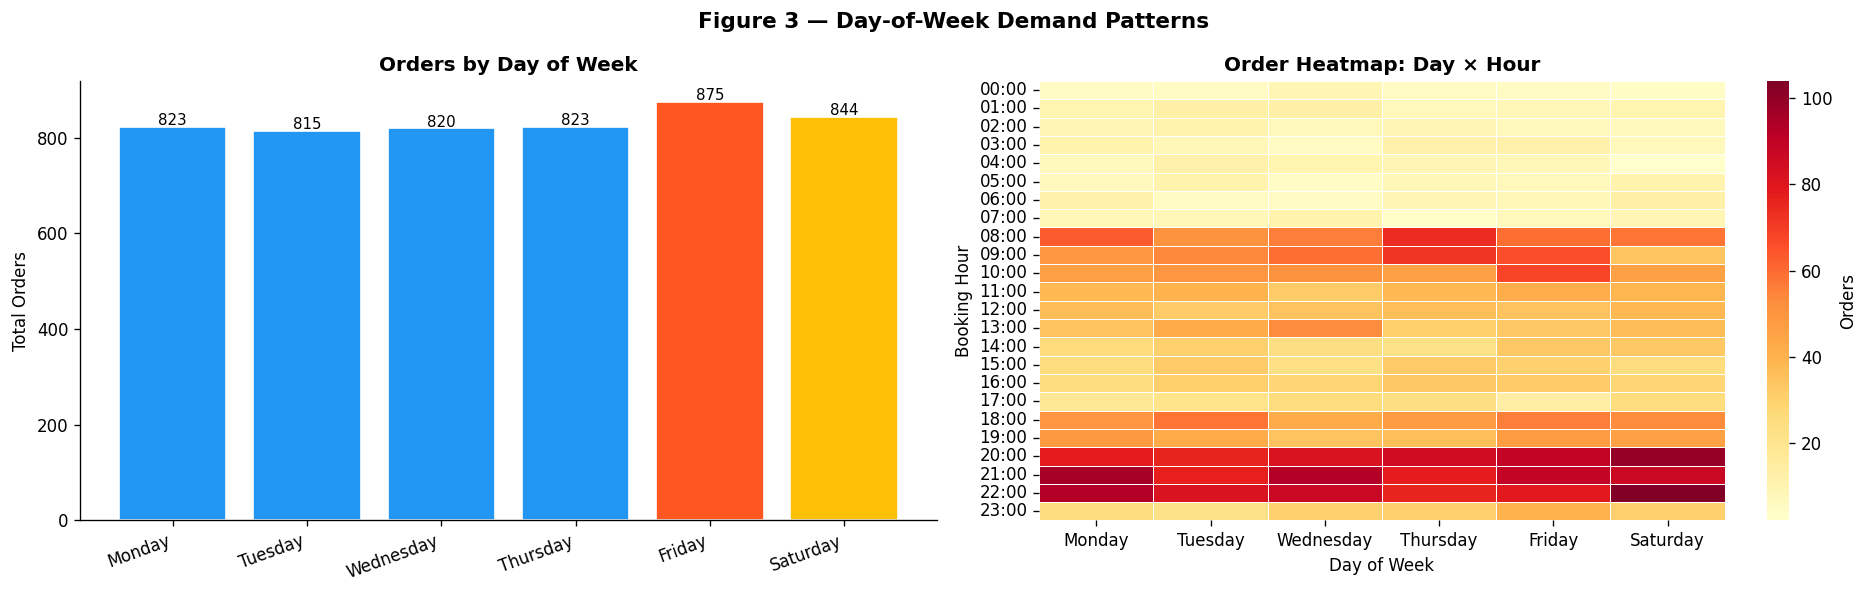

booking_day_of_week  orders  order_pct  revenue   avg_val
             Monday     823       16.5 62753.43 76.249611
            Tuesday     815       16.3 67874.04 83.281031
          Wednesday     820       16.4 70853.56 86.406780
           Thursday     823       16.5 64671.87 78.580644
             Friday     875       17.5 68560.61 78.354983
           Saturday     844       16.9 62274.56 73.785024


In [5]:
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
dow = (
    df.groupby('booking_day_of_week')
    .agg(
        orders  = ('order_id',       'count'),
        revenue = ('order_value_sgd', 'sum'),
        avg_val = ('order_value_sgd', 'mean'),
    )
    .reindex([d for d in DOW_ORDER if d in df['booking_day_of_week'].unique()])
    .reset_index()
)
dow['order_pct'] = (dow['orders'] / dow['orders'].sum() * 100).round(1)

# Heatmap: hour x day
hour_dow_pivot = (
    df.groupby(['booking_day_of_week', 'booking_hour'])['order_id']
    .count()
    .unstack(fill_value=0)
    .reindex([d for d in DOW_ORDER if d in df['booking_day_of_week'].unique()])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
dow_colours = [C_ORANGE if v == dow['orders'].max() else
               C_AMBER  if v >= dow['orders'].quantile(0.75) else C_BLUE
               for v in dow['orders']]
bars = axes[0].bar(dow['booking_day_of_week'], dow['orders'],
                   color=dow_colours, edgecolor='white')
for bar, v in zip(bars, dow['orders']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 str(v), ha='center', fontsize=9)
axes[0].set_ylabel('Total Orders')
axes[0].set_title('Orders by Day of Week')
axes[0].set_xticklabels(dow['booking_day_of_week'], rotation=20, ha='right')

# Heatmap hour x day
sns.heatmap(hour_dow_pivot.T, cmap='YlOrRd', ax=axes[1],
            linewidths=0.3, cbar_kws={'label': 'Orders'},
            yticklabels=[f'{h:02d}:00' for h in hour_dow_pivot.T.index])
axes[1].set_title('Order Heatmap: Day × Hour')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Booking Hour')

plt.suptitle('Figure 3 — Day-of-Week Demand Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_dow_patterns.png', bbox_inches='tight')
plt.show()

print(dow[['booking_day_of_week','orders','order_pct','revenue','avg_val']].to_string(index=False))

---
## 5. Monthly & Seasonal Trends
How does demand evolve month by month? Spot seasonal peaks to plan staffing in advance.

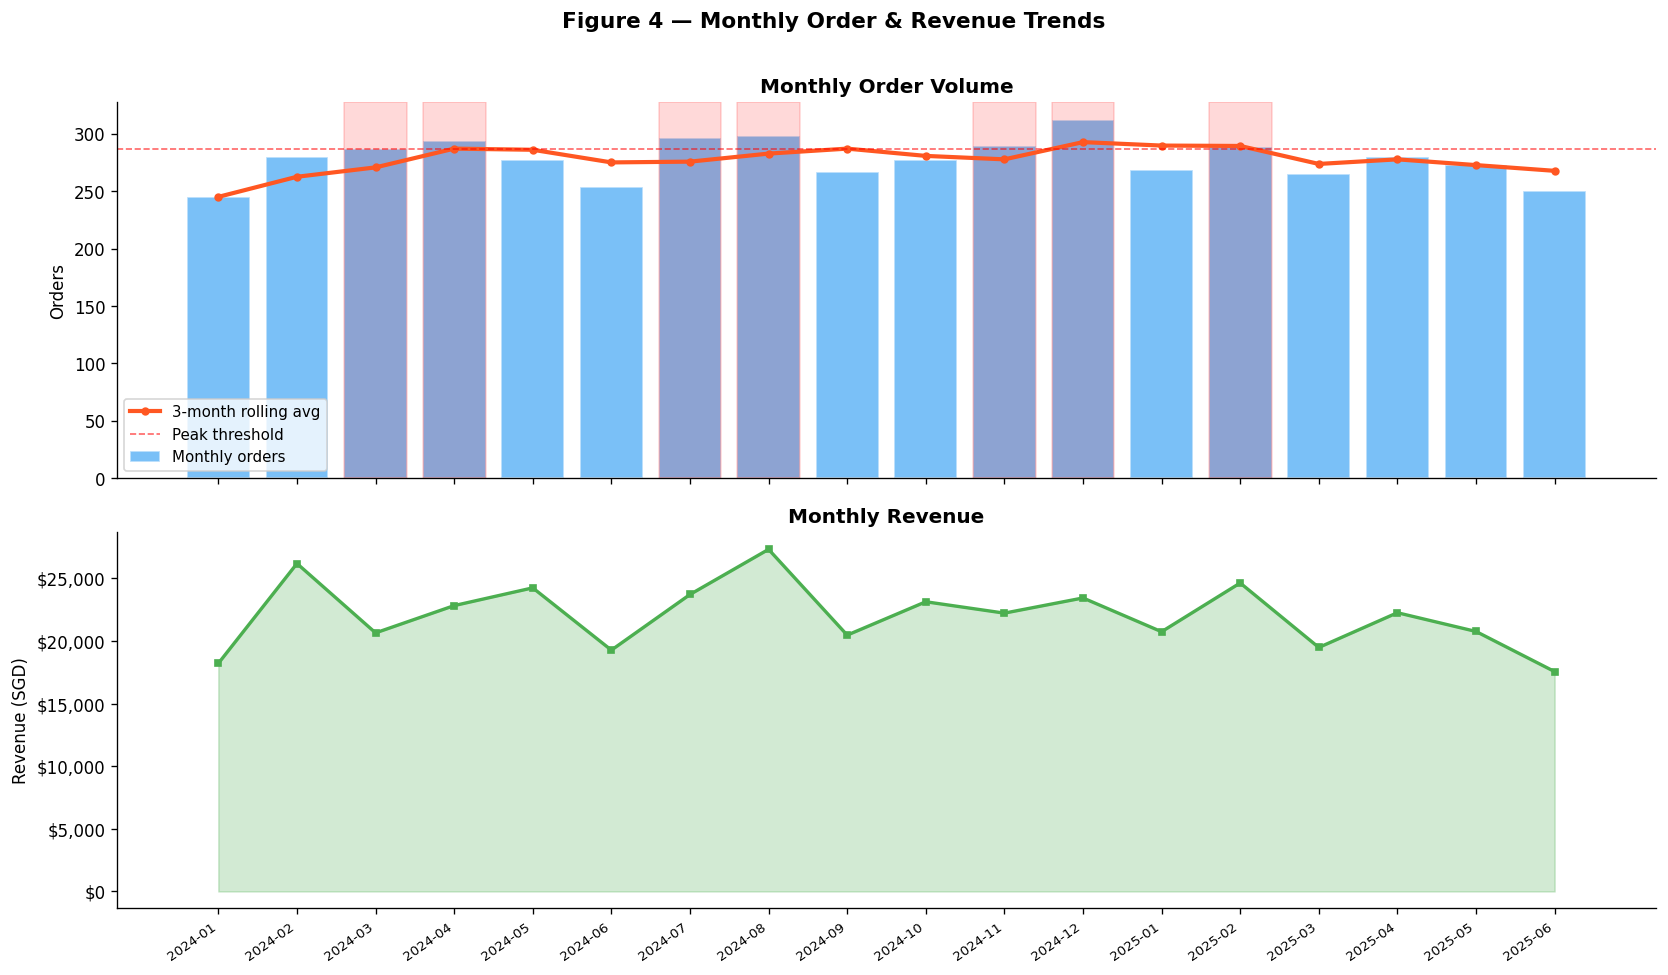

Peak month : 2024-12 (312 orders)
Quiet month: 2024-01  (245 orders)


In [6]:
monthly = (
    df.groupby('year_month')
    .agg(
        orders  = ('order_id',        'count'),
        revenue = ('order_value_sgd',  'sum'),
    )
    .reset_index()
)
monthly['year_month_str'] = monthly['year_month'].astype(str)
monthly['rolling3']       = monthly['orders'].rolling(3, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Orders trend
ax = axes[0]
ax.bar(range(len(monthly)), monthly['orders'], color=C_BLUE, alpha=0.6,
       edgecolor='white', label='Monthly orders')
ax.plot(range(len(monthly)), monthly['rolling3'], color=C_ORANGE,
        linewidth=2.5, marker='o', markersize=4, label='3-month rolling avg')
# Shade peak months (above rolling mean + 0.5 std)
peak_thresh = monthly['orders'].mean() + 0.5 * monthly['orders'].std()
for i, row in monthly.iterrows():
    if row['orders'] > peak_thresh:
        ax.axvspan(i-0.4, i+0.4, alpha=0.15, color='red')
ax.axhline(peak_thresh, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Peak threshold')
ax.set_ylabel('Orders')
ax.set_title('Monthly Order Volume', fontweight='bold')
ax.legend(fontsize=9)

# Revenue trend
ax2 = axes[1]
ax2.fill_between(range(len(monthly)), monthly['revenue'], alpha=0.25, color=C_GREEN)
ax2.plot(range(len(monthly)), monthly['revenue'], color=C_GREEN, linewidth=2, marker='s', markersize=4)
ax2.set_ylabel('Revenue (SGD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.set_title('Monthly Revenue', fontweight='bold')

# X labels
tick_step = max(1, len(monthly)//12)
ax2.set_xticks(range(0, len(monthly), tick_step))
ax2.set_xticklabels(monthly['year_month_str'].iloc[::tick_step], rotation=35, ha='right', fontsize=8)

plt.suptitle('Figure 4 — Monthly Order & Revenue Trends', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_monthly_trend.png', bbox_inches='tight')
plt.show()

peak_month = monthly.loc[monthly['orders'].idxmax(), 'year_month_str']
low_month  = monthly.loc[monthly['orders'].idxmin(), 'year_month_str']
print(f'Peak month : {peak_month} ({monthly["orders"].max()} orders)')
print(f'Quiet month: {low_month}  ({monthly["orders"].min()} orders)')

---
## 6. Weekly Demand Heatmap
A week-by-week view to spot recurring surges and plan ahead.

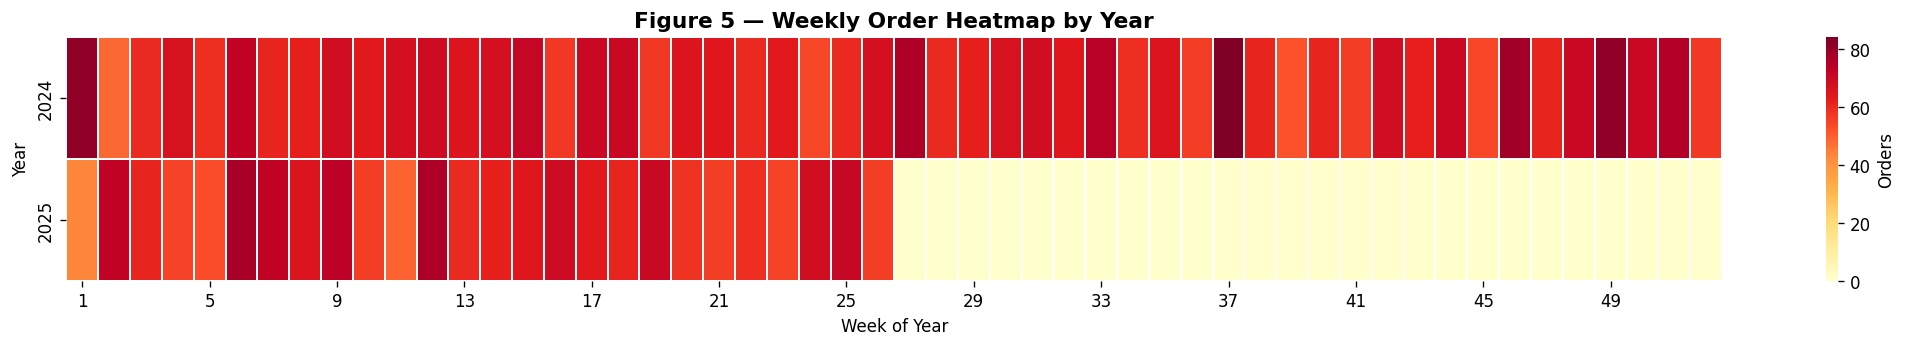

In [7]:
weekly = (
    df.groupby(['booking_year','booking_week'])['order_id']
    .count()
    .reset_index(name='orders')
    .sort_values(['booking_year','booking_week'])
    .reset_index(drop=True)
)
weekly['period'] = weekly['booking_year'].astype(str) + '-W' + weekly['booking_week'].astype(str).str.zfill(2)

# Pivot: year as row, week-of-year as column
weekly_pivot = weekly.pivot_table(index='booking_year', columns='booking_week',
                                   values='orders', fill_value=0)

fig, ax = plt.subplots(figsize=(18, 3))
sns.heatmap(weekly_pivot, cmap='YlOrRd', ax=ax, linewidths=0.2,
            cbar_kws={'label': 'Orders'},
            xticklabels=4)
ax.set_title('Figure 5 — Weekly Order Heatmap by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Week of Year')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('fig5_weekly_heatmap.png', bbox_inches='tight')
plt.show()

---
## 7. Collection Slot & Delivery Slot Analysis
Which pickup and delivery slots are most in demand? This directly drives rider allocation per window.

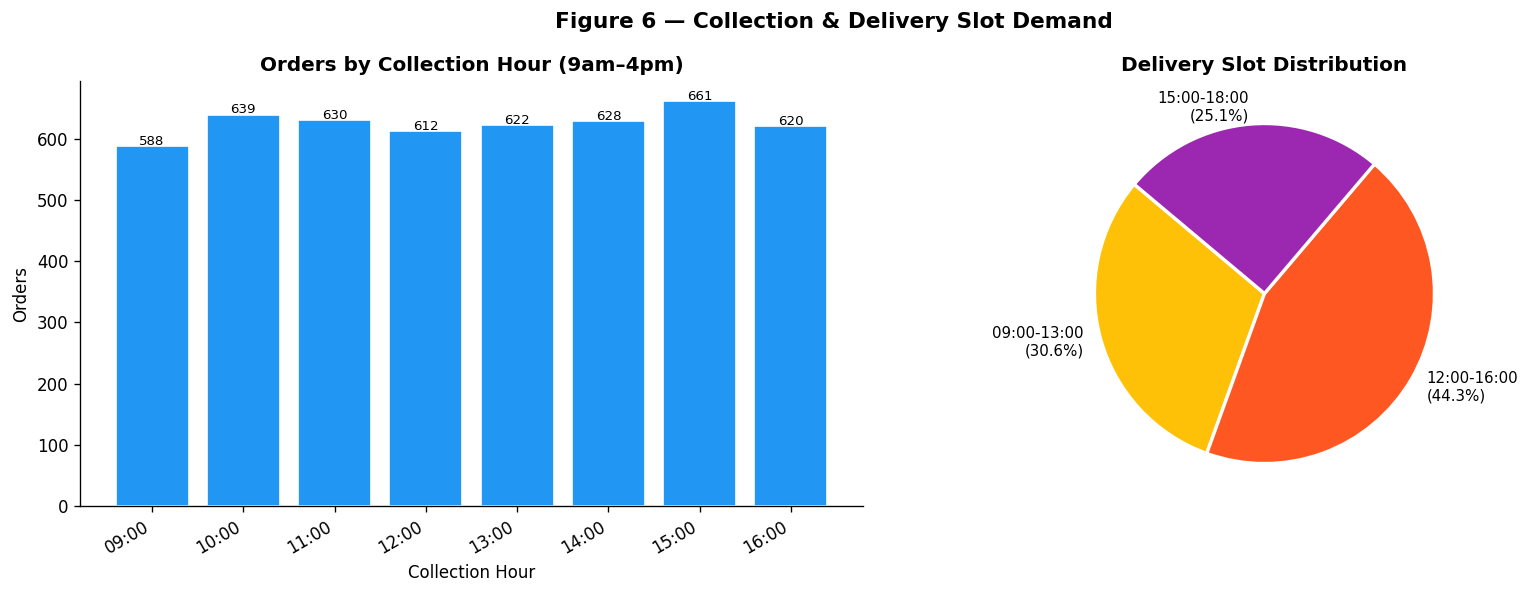

Most popular delivery slot : 12:00-16:00 (2215 orders)
Collection hours are evenly spread 9am-4pm (588-661 orders/hr)


In [8]:
# Collection hour distribution
col_hour = df.groupby('collection_hour')['order_id'].count().reset_index(name='orders')
col_hour['order_pct'] = (col_hour['orders'] / col_hour['orders'].sum() * 100).round(1)

# Delivery slot distribution
del_slot = df.groupby('delivery_slot')['order_id'].count().reset_index(name='orders')
del_slot['order_pct'] = (del_slot['orders'] / del_slot['orders'].sum() * 100).round(1)

SLOT_COLOURS = {'09:00-13:00': C_AMBER, '12:00-16:00': C_ORANGE, '15:00-18:00': C_PURPLE}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Collection hour bar
bars = axes[0].bar(col_hour['collection_hour'], col_hour['orders'],
                   color=C_BLUE, edgecolor='white')
for bar, v in zip(bars, col_hour['orders']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 str(v), ha='center', fontsize=8)
axes[0].set_xlabel('Collection Hour')
axes[0].set_ylabel('Orders')
axes[0].set_xticks(col_hour['collection_hour'])
axes[0].set_xticklabels([f'{h:02d}:00' for h in col_hour['collection_hour']], rotation=30, ha='right')
axes[0].set_title('Orders by Collection Hour (9am–4pm)')

# Delivery slot pie
slot_colours = [SLOT_COLOURS.get(s, C_BLUE) for s in del_slot['delivery_slot']]
axes[1].pie(del_slot['order_pct'],
            labels=[f"{r['delivery_slot']}\n({r['order_pct']}%)" for _,r in del_slot.iterrows()],
            colors=slot_colours, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize': 9})
axes[1].set_title('Delivery Slot Distribution')

plt.suptitle('Figure 6 — Collection & Delivery Slot Demand', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_slot_demand.png', bbox_inches='tight')
plt.show()

top_del = del_slot.loc[del_slot['orders'].idxmax(), 'delivery_slot']
print(f'Most popular delivery slot : {top_del} ({del_slot["orders"].max()} orders)')
print(f'Collection hours are evenly spread 9am-4pm ({col_hour["orders"].min()}-{col_hour["orders"].max()} orders/hr)')

---
## 8. Delivery Slot × Day-of-Week Heatmap
Reveals which day + slot combinations are highest pressure on riders.

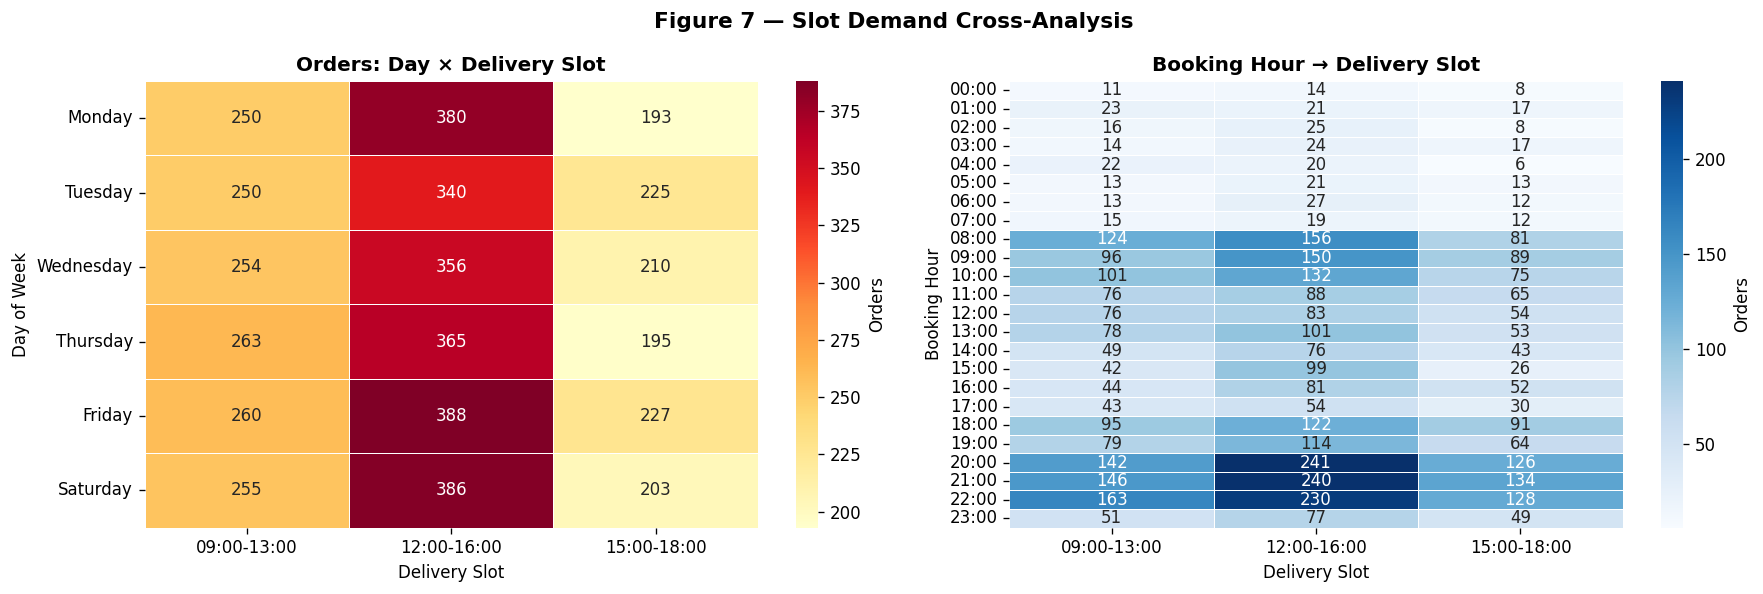

Tip: dark cells = highest rider demand. Schedule most riders for these day+slot combos.


In [9]:
slot_dow_pivot = (
    df.groupby(['booking_day_of_week', 'delivery_slot'])['order_id']
    .count()
    .unstack(fill_value=0)
    .reindex([d for d in DOW_ORDER if d in df['booking_day_of_week'].unique()])
)

# Also: booking hour x delivery slot
hour_slot_pivot = (
    df.groupby(['booking_hour', 'delivery_slot'])['order_id']
    .count()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(slot_dow_pivot, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Orders'})
axes[0].set_title('Orders: Day × Delivery Slot')
axes[0].set_xlabel('Delivery Slot')
axes[0].set_ylabel('Day of Week')

sns.heatmap(hour_slot_pivot, annot=True, fmt='d', cmap='Blues',
            ax=axes[1], linewidths=0.3, cbar_kws={'label': 'Orders'},
            yticklabels=[f'{h:02d}:00' for h in hour_slot_pivot.index])
axes[1].set_title('Booking Hour → Delivery Slot')
axes[1].set_xlabel('Delivery Slot')
axes[1].set_ylabel('Booking Hour')

plt.suptitle('Figure 7 — Slot Demand Cross-Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_slot_crossanalysis.png', bbox_inches='tight')
plt.show()
print('Tip: dark cells = highest rider demand. Schedule most riders for these day+slot combos.')

---
## 9. Zone × Booking Hour Analysis
Which zones are placing orders at which hours? Enables geo-targeted rider dispatch.

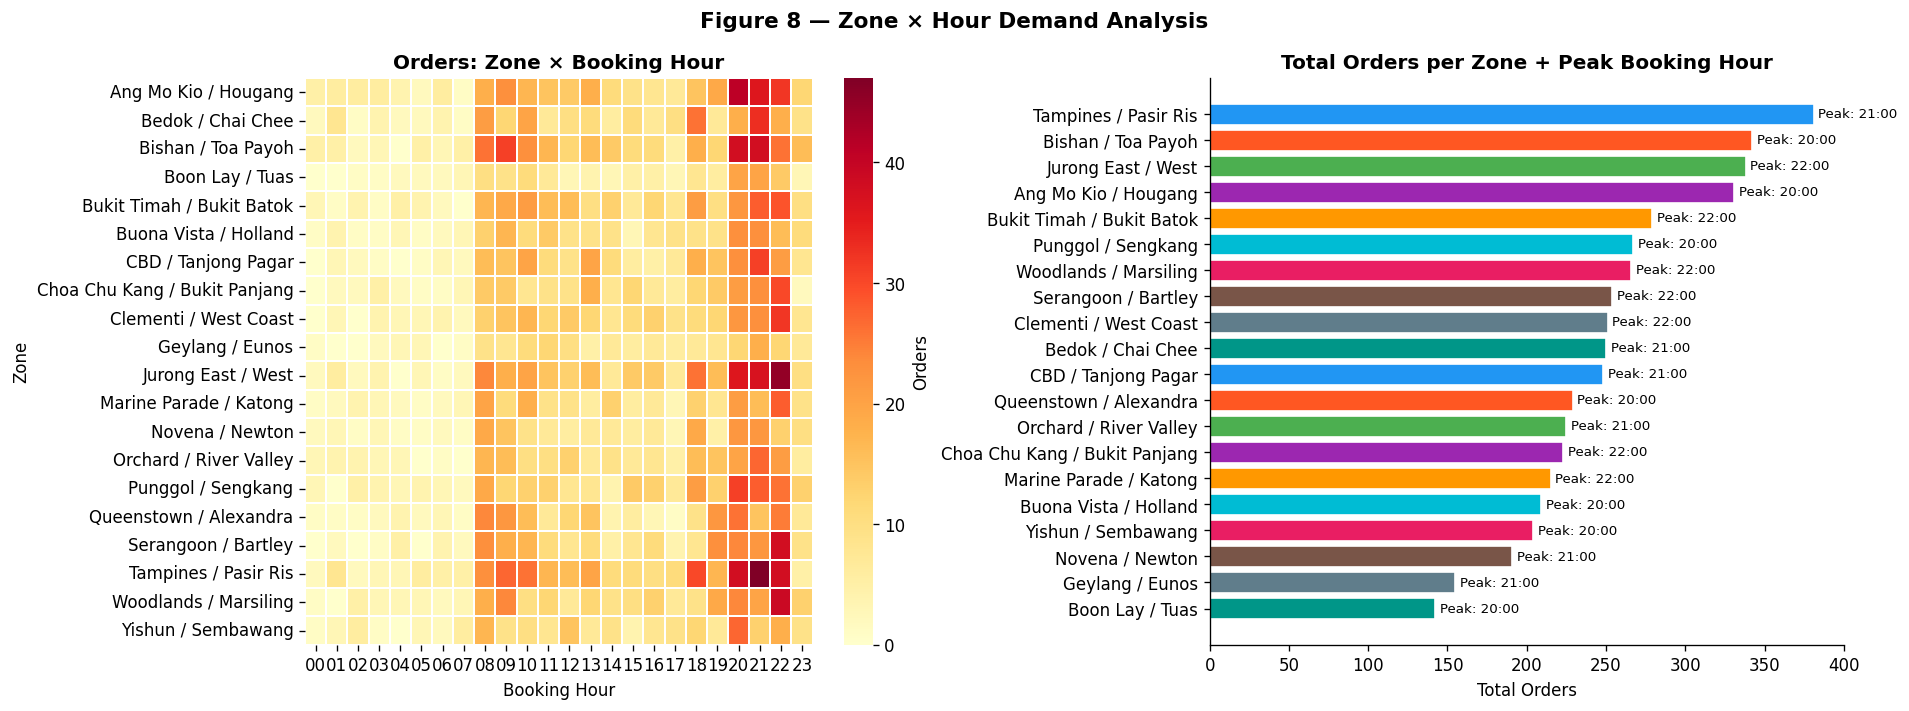

Zone peak booking hours:
                         zone  total_orders  peak_hour
         Tampines / Pasir Ris           381         21
           Bishan / Toa Payoh           342         20
           Jurong East / West           338         22
         Ang Mo Kio / Hougang           331         20
    Bukit Timah / Bukit Batok           279         22
           Punggol / Sengkang           267         20
        Woodlands / Marsiling           266         22
          Serangoon / Bartley           254         22
        Clementi / West Coast           251         22
            Bedok / Chai Chee           250         21
          CBD / Tanjong Pagar           248         21
       Queenstown / Alexandra           229         20
       Orchard / River Valley           225         21
Choa Chu Kang / Bukit Panjang           223         22
       Marine Parade / Katong           215         22
        Buona Vista / Holland           209         20
           Yishun / Sembawang           

In [10]:
zone_hour_pivot = (
    df.groupby(['zone', 'booking_hour'])['order_id']
    .count()
    .unstack(fill_value=0)
)

# Zone peak hour
zone_peak = (
    df.groupby(['zone', 'booking_hour'])['order_id'].count()
    .reset_index(name='orders')
    .sort_values('orders', ascending=False)
    .drop_duplicates('zone')
    .rename(columns={'booking_hour':'peak_hour'})
)
zone_orders = df.groupby('zone')['order_id'].count().reset_index(name='total_orders')
zone_peak   = zone_peak.merge(zone_orders, on='zone').sort_values('total_orders', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap zone x hour
sns.heatmap(zone_hour_pivot, cmap='YlOrRd', ax=axes[0],
            linewidths=0.2, cbar_kws={'label': 'Orders'},
            xticklabels=[f'{h:02d}' for h in zone_hour_pivot.columns])
axes[0].set_title('Orders: Zone × Booking Hour')
axes[0].set_xlabel('Booking Hour')
axes[0].set_ylabel('Zone')

# Zone peak hour scatter
zone_colours = [ZONE_PALETTE[i % len(ZONE_PALETTE)] for i in range(len(zone_peak))]
bars = axes[1].barh(zone_peak['zone'], zone_peak['total_orders'],
                    color=zone_colours, edgecolor='white')
for bar, row in zip(bars, zone_peak.itertuples()):
    axes[1].text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
                 f'Peak: {row.peak_hour:02d}:00', va='center', fontsize=8)
axes[1].set_xlabel('Total Orders')
axes[1].set_title('Total Orders per Zone + Peak Booking Hour')
axes[1].invert_yaxis()

plt.suptitle('Figure 8 — Zone × Hour Demand Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_zone_hour.png', bbox_inches='tight')
plt.show()

print('Zone peak booking hours:')
print(zone_peak[['zone','total_orders','peak_hour']].to_string(index=False))

---
## 10. Rider Demand Forecast
Estimate how many riders are needed per time slot, based on order volume.
**Assumption**: 1 rider handles ~15 orders per slot window.

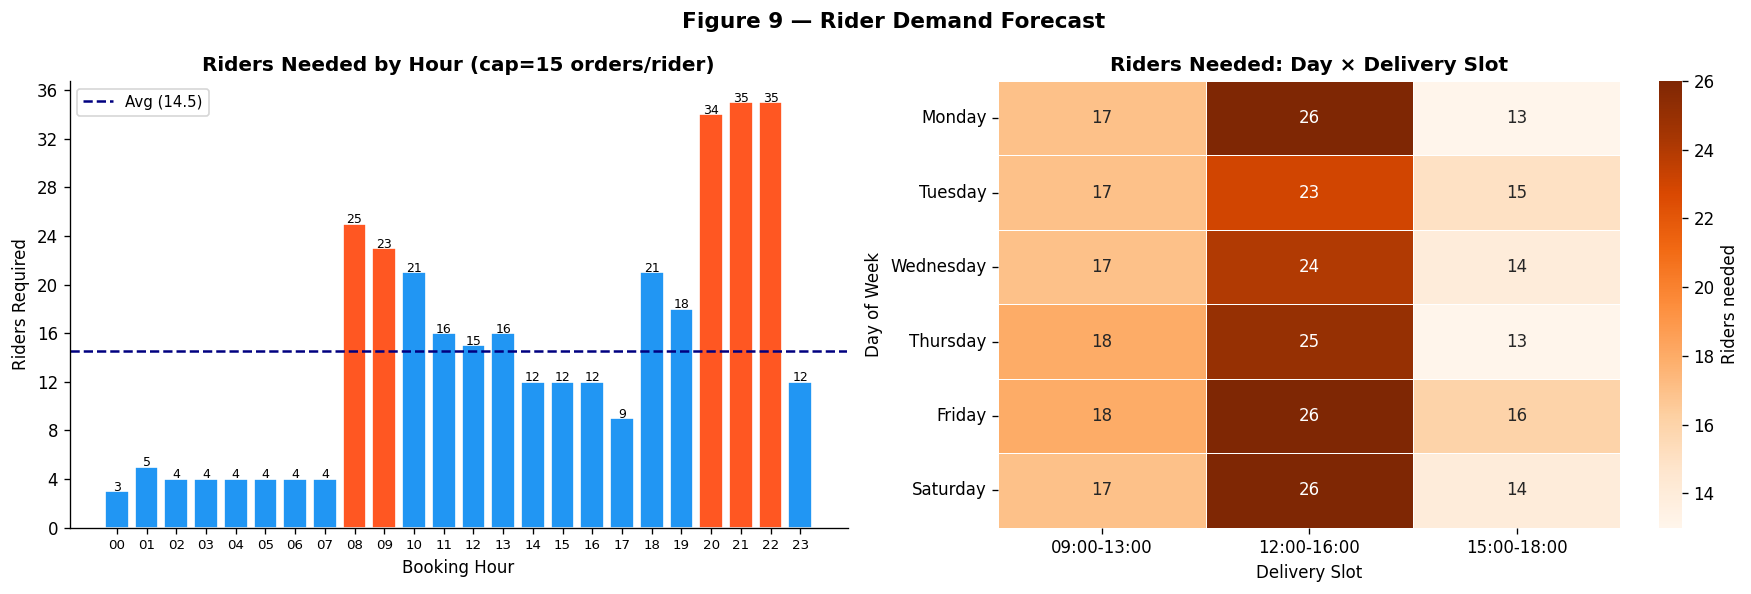

Max riders needed in a single hour: 35 at 21:00
Average riders needed per hour    : 14.5


In [11]:
RIDER_CAPACITY = 15   # orders per rider per slot

# Riders needed per hour
hourly['riders_needed'] = np.ceil(hourly['orders'] / RIDER_CAPACITY).astype(int)

# Riders needed per delivery slot x DOW
slot_dow_riders = np.ceil(slot_dow_pivot / RIDER_CAPACITY).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hourly rider requirement
ax = axes[0]
peak_mask = hourly['is_peak']
ax.bar(hourly['booking_hour'], hourly['riders_needed'],
       color=[C_ORANGE if p else C_BLUE for p in peak_mask],
       edgecolor='white')
ax.axhline(hourly['riders_needed'].mean(), color='navy', linestyle='--',
           linewidth=1.5, label=f"Avg ({hourly['riders_needed'].mean():.1f})")
for i, row in hourly.iterrows():
    ax.text(row['booking_hour'], row['riders_needed']+0.05,
            str(row['riders_needed']), ha='center', fontsize=7.5)
ax.set_xlabel('Booking Hour')
ax.set_ylabel('Riders Required')
ax.set_title(f'Riders Needed by Hour (cap={RIDER_CAPACITY} orders/rider)')
ax.set_xticks(range(0,24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)], fontsize=8)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(fontsize=9)

# Slot x DOW rider heatmap
sns.heatmap(slot_dow_riders, annot=True, fmt='d', cmap='Oranges',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Riders needed'})
axes[1].set_title(f'Riders Needed: Day × Delivery Slot')
axes[1].set_xlabel('Delivery Slot')
axes[1].set_ylabel('Day of Week')

plt.suptitle('Figure 9 — Rider Demand Forecast', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_rider_forecast.png', bbox_inches='tight')
plt.show()

peak_rider_hour = hourly.loc[hourly['riders_needed'].idxmax()]
print(f'Max riders needed in a single hour: {peak_rider_hour["riders_needed"]} at {int(peak_rider_hour["booking_hour"]):02d}:00')
print(f'Average riders needed per hour    : {hourly["riders_needed"].mean():.1f}')

---
## 11. Key Insights & Recommendations

In [12]:
print('=' * 65)
print('  ASTORIA — PEAK DEMAND TIMING FINDINGS')
print('=' * 65)

# Peak hours
peak_hrs = hourly[hourly['is_peak']].sort_values('orders', ascending=False)
top_hour  = peak_hrs.iloc[0]
print(f'\n1. PEAK BOOKING HOURS')
for _, r in peak_hrs.iterrows():
    print(f'   {int(r["booking_hour"]):02d}:00  {r["orders"]:>4} orders  ({r["order_pct"]}%)')

print(f'\n2. PERIOD BREAKDOWN')
for _, r in period_summary.sort_values('orders', ascending=False).iterrows():
    flag = ' ← HIGH DEMAND' if r['order_pct'] >= 15 else ''
    print(f'   {r["booking_period"]:<25} {r["orders"]:>5} orders ({r["order_pct"]}%){flag}')

print(f'\n3. DAY-OF-WEEK')
busiest_day = dow.loc[dow['orders'].idxmax()]
quietest_day = dow.loc[dow['orders'].idxmin()]
print(f'   Busiest : {busiest_day["booking_day_of_week"]} ({busiest_day["orders"]} orders)')
print(f'   Quietest: {quietest_day["booking_day_of_week"]} ({quietest_day["orders"]} orders)')

print(f'\n4. DELIVERY SLOT DEMAND')
for _, r in del_slot.sort_values('orders', ascending=False).iterrows():
    print(f'   {r["delivery_slot"]}  {r["orders"]:>5} orders ({r["order_pct"]}%)')

print(f'\n5. TOP ZONE BY VOLUME')
top_zone = zone_orders.sort_values('total_orders', ascending=False).iloc[0]
print(f'   {top_zone["zone"]} — {top_zone["total_orders"]} orders')

print(f'\nRECOMMENDATIONS')
top_h = int(peak_hrs.iloc[0]["booking_hour"])
print(f'   1. Open extra booking slots between {top_h:02d}:00-{top_h+2:02d}:00 — highest demand window')
print(f'   2. Increase riders for 12:00-16:00 delivery slot — most popular slot')
print(f'   3. Roster maximum riders on {busiest_day["booking_day_of_week"]}s')
print(f'   4. Offer incentive pricing on {quietest_day["booking_day_of_week"]}s to smooth demand')
print(f'   5. Send booking reminders/promos before 20:00 to capture evening demand early')
print(f'   6. Prioritise rider standby in {top_zone["zone"]} — highest order concentration')
print('\n' + '=' * 65)

  ASTORIA — PEAK DEMAND TIMING FINDINGS

1. PEAK BOOKING HOURS
   22:00   521 orders  (10.4%)
   21:00   520 orders  (10.4%)
   20:00   509 orders  (10.2%)
   08:00   361 orders  (7.2%)
   09:00   335 orders  (6.7%)

2. PERIOD BREAKDOWN
   Night (21-23)              1218 orders (24.4%) ← HIGH DEMAND
   Evening (18-20)            1074 orders (21.5%) ← HIGH DEMAND
   Morning (9-11)              872 orders (17.4%) ← HIGH DEMAND
   Afternoon (14-17)           639 orders (12.8%)
   Early Morning (6-8)         459 orders (9.2%)
   Lunch (12-13)               445 orders (8.9%)
   Late Night (0-5)            293 orders (5.9%)

3. DAY-OF-WEEK
   Busiest : Friday (875 orders)
   Quietest: Tuesday (815 orders)

4. DELIVERY SLOT DEMAND
   12:00-16:00   2215 orders (44.3%)
   09:00-13:00   1532 orders (30.6%)
   15:00-18:00   1253 orders (25.1%)

5. TOP ZONE BY VOLUME
   Tampines / Pasir Ris — 381 orders

RECOMMENDATIONS
   1. Open extra booking slots between 22:00-24:00 — highest demand window
   